In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
import warnings
from glob import glob

import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
df = pd.read_csv("/content/real_estates1.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21703 entries, 0 to 21702
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bhk                  21703 non-null  object 
 1   price                20827 non-null  object 
 2   price_per_sqft       20589 non-null  object 
 3   super_built_up_area  7190 non-null   object 
 4   carpet_area          13464 non-null  object 
 5   bedroom              20784 non-null  float64
 6   bathroom             20002 non-null  float64
 7   balconies            9475 non-null   float64
 8   status               17714 non-null  object 
 9   transaction_type     20818 non-null  object 
 10  funrished_status     18975 non-null  object 
 11  address              20827 non-null  object 
 12  facing               11920 non-null  object 
 13  floorNum             17579 non-null  object 
 14  projectName          13230 non-null  object 
 15  additional_room      5279 non-null  

In [ ]:
df1 = df[["bhk","price","price_per_sqft","bedroom","bathroom","transaction_type","funrished_status","address","localities","regions","lats","longs"]]

In [ ]:
df1["price_per_sqft"] = df1["price_per_sqft"].str.split("/", expand= True)[0]

/tmp/ipython-input-3933739221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["price_per_sqft"] = df1["price_per_sqft"].str.split("/", expand= True)[0]


In [ ]:
df1["price_per_sqft"]=df1["price_per_sqft"].str.replace(",", "", regex =False)

/tmp/ipython-input-3718486903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["price_per_sqft"]=df1["price_per_sqft"].str.replace(",", "", regex =False)


In [ ]:
df1["price_per_sqft"]=df1["price_per_sqft"].astype(float)

/tmp/ipython-input-3329800687.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["price_per_sqft"]=df1["price_per_sqft"].astype(float)


In [ ]:
def convert_str_to_float(Price_str):
  if "Cr" in Price_str:
    return float(Price_str.replace("Cr", "")) * 10000000
  elif "L" in Price_str:
    return float(Price_str.replace("Lac", "")) * 100000

df1["price_rupees"] = df1["price_rupees"].apply(convert_str_to_float)

/tmp/ipython-input-889212982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["price_rupees"] = df1["price_rupees"].apply(convert_str_to_float)


In [ ]:
df1["price_usd"] = (df1["price_rupees"]/87.9).round(2)

/tmp/ipython-input-323625566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["price_usd"] = (df1["price_rupees"]/87.9).round(2)


In [ ]:
df1.head()

,bhk,price,price_per_sqft,bedroom,bathroom,transaction_type,funrished_status,address,localities,regions,lats,longs,price_rupees,price_usd,surface_covered_in_sqft
0,3-bhk-1377-sq-ft-multistorey-apartment-for-sal...,"₹52 Lac | ₹2,91,199 Approx. Registration Charges",4333.0,3.0,2.0,Resale,Unfurnished,Kammasandra Main Road Shree Ananth Nagar Layou...,Electronic City Phase 2,Bangalore,12.839136,77.698975,5200000.0,59158.13,1200.0
2,3-bhk-1608-sq-ft-multistorey-apartment-for-sal...,₹1.64 Cr,10217.0,3.0,3.0,New Property,Unfurnished,"Sarjapur Road, Bangalore - South, Karnataka",Sarjapur Road,Bangalore,12.912350,77.680996,16400000.0,186575.65,1605.0
3,2-bhk-1417-sq-ft-multistorey-apartment-for-sal...,"₹1.41 Cr | ₹7,95,152 Approx. Registration Char...",14915.0,2.0,2.0,New Property,Unfurnished,"Begur - Koppa Rd, Suraksha nagar, Yelenahalli,...",Begur Hulimavu Road,Bangalore,12.865125,77.621071,14100000.0,160409.56,945.0
4,3-bhk-1410-sq-ft-multistorey-apartment-for-sal...,"₹67 Lac | ₹3,75,199 Approx. Registration Charges",4751.0,3.0,2.0,New Property,Unfurnished,"Electronic City, Bangalore, Electronics City P...",Electronics City Phase 1,Bangalore,12.833951,77.675366,6700000.0,76222.98,1410.0
5,3-bhk-1200-sq-ft-villa-for-sale-chandapura-in-...,"₹1.05 Cr | ₹5,87,999 Approx. Registration Char...",8750.0,3.0,3.0,New Property,Unfurnished,"Jigani, Chandapura, Bangalore - South, Karnataka",Chandapura,Bangalore,12.798481,77.713809,10500000.0,119453.92,1200.0


In [ ]:
df1['price_usd'].value_counts()

,count
price_usd,
170648.46,346
113765.64,325
136518.77,325
125142.21,322
85324.23,292
...,...
92036.41,1
99317.41,1
112514.22,1


In [ ]:
df1["surface_covered_in_sqft"] = round(df1["price_rupees"]/df1["price_per_sqft"],0)

/tmp/ipython-input-1494528034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["surface_covered_in_sqft"] = round(df1["price_rupees"]/df1["price_per_sqft"],0)


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17666 entries, 0 to 21702
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bhk                      17666 non-null  object 
 1   price                    17666 non-null  object 
 2   price_per_sqft           17666 non-null  float64
 3   bedroom                  17666 non-null  float64
 4   bathroom                 17666 non-null  float64
 5   transaction_type         17666 non-null  object 
 6   funrished_status         17666 non-null  object 
 7   address                  17666 non-null  object 
 8   localities               17666 non-null  object 
 9   regions                  17666 non-null  object 
 10  lats                     17666 non-null  float64
 11  longs                    17666 non-null  float64
 12  price_rupees             17666 non-null  float64
 13  price_usd                17666 non-null  float64
 14  surface_covered_in_sqft  17

In [ ]:
# Drop null values from df1
df1.dropna(inplace=True)

/tmp/ipython-input-2042317296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.dropna(inplace=True)


In [ ]:
df1.to_csv("cleaned_real_estate_data.csv", index=False)

In [ ]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["regions"].str.contains("Bangalore")
    mask_apt = df["bhk"].str.contains("apartment")
    mask_price = df["price_usd"] < 500_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_sqft"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_sqft"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    #df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    #df.drop(columns="lat-lon", inplace=True)

    # Get place name
    #df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    #df.drop(columns="place_with_parent_names", inplace=True)

    #drop low and high cardinality categorical variables
    df.drop(columns=["bhk", "price", "address"], inplace=True)

    # drop leaky columns
    df.drop(columns=[
        "price_per_sqft",
        "price_rupees"
    ],
            inplace= True)

    #drop columns with multicollinearlity
    df.drop(columns=["bedroom", "bathroom"], inplace=True)

    return df

In [ ]:
frame1 = wrangle("/content/cleaned_real_estate_data.csv")
print(frame1.info())
frame1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3585 entries, 0 to 17665
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_type         3585 non-null   object 
 1   funrished_status         3585 non-null   object 
 2   localities               3585 non-null   object 
 3   regions                  3585 non-null   object 
 4   lats                     3585 non-null   float64
 5   longs                    3585 non-null   float64
 6   price_usd                3585 non-null   float64
 7   surface_covered_in_sqft  3585 non-null   float64
dtypes: float64(4), object(4)
memory usage: 252.1+ KB
None


,transaction_type,funrished_status,localities,regions,lats,longs,price_usd,surface_covered_in_sqft
0,Resale,Unfurnished,Electronic City Phase 2,Bangalore,12.839136,77.698975,59158.13,1200.0
1,New Property,Unfurnished,Sarjapur Road,Bangalore,12.912350,77.680996,186575.65,1605.0
2,New Property,Unfurnished,Begur Hulimavu Road,Bangalore,12.865125,77.621071,160409.56,945.0
3,New Property,Unfurnished,Electronics City Phase 1,Bangalore,12.833951,77.675366,76222.98,1410.0
6,New Property,Unfurnished,Sarjapur,Bangalore,12.912350,77.680996,144482.37,1460.0


In [ ]:
frame1.select_dtypes("object").head()

,transaction_type,funrished_status,localities,regions
0,Resale,Unfurnished,Electronic City Phase 2,Bangalore
1,New Property,Unfurnished,Sarjapur Road,Bangalore
2,New Property,Unfurnished,Begur Hulimavu Road,Bangalore
3,New Property,Unfurnished,Electronics City Phase 1,Bangalore
6,New Property,Unfurnished,Sarjapur,Bangalore


In [ ]:
frame1.select_dtypes("object").nunique()

,0
transaction_type,4
funrished_status,3
localities,684
regions,1


In [ ]:
sorted(frame1.columns)

['funrished_status',
 'lats',
 'localities',
 'longs',
 'price_usd',
 'regions',
 'surface_covered_in_sqft',
 'transaction_type']

<Axes: >

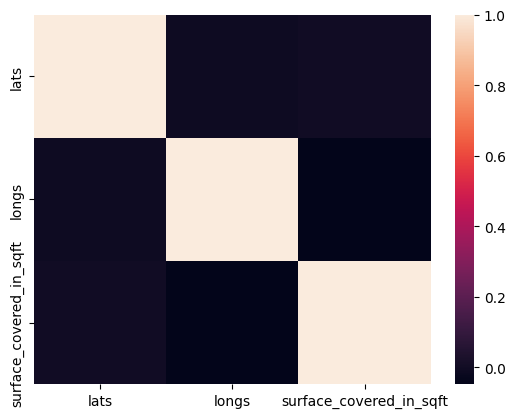

In [ ]:
corr = frame1.select_dtypes("number").drop(columns="price_usd").corr()
sns.heatmap(corr)

In [ ]:
target = "price_usd"
features = ["surface_covered_in_sqft","lats","longs","localities"]
y_train = frame1[target]
X_train = frame1[features]

In [ ]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)

print("Mean apt price:", round(y_mean, 2))

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 167585.74
Baseline MAE: 66951.30216595337


In [ ]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)

model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['localities'], use_cat_names=True)),
                ('simpleimputer', SimpleImputer()), ('ridge', Ridge())])

In [ ]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", mae_training)

Training MAE: 41570.04286320893


In [ ]:
def make_prediction(area, lats, longs, localities):
    data = {
        "surface_covered_in_sqft": area,
        "lats": lats,
        "longs": longs,
        "localities": localities
    }
    df = pd.DataFrame(data, index= [0])
    prediction = model.predict(df).round(2)[0]
    return f"Predicted apartment price: ${prediction}"

In [ ]:
make_prediction(1100, 12.6340, 77.4621, "Sarjapur Road")

'Predicted apartment price: $147855.76'

In [ ]:
# interactive dashboard,

interact(
    make_prediction,
    area=IntSlider(
        min=X_train["surface_covered_in_sqft"].min(),
        max=X_train["surface_covered_in_sqft"].max(),
        value=X_train["surface_covered_in_sqft"].mean(),
    ),
    lats=FloatSlider(
        min=X_train["lats"].min(),
        max=X_train["lats"].max(),
        step=0.01,
        value=X_train["lats"].mean(),
    ),
    longs=FloatSlider(
        min=X_train["longs"].min(),
        max=X_train["longs"].max(),
        step=0.01,
        value=X_train["longs"].mean(),
    ),
    localities=Dropdown(options=sorted(X_train["localities"].unique())),
);

interactive(children=(IntSlider(value=1312, description='area', max=1990, min=900), FloatSlider(value=12.97734…